In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv(r"C:\Users\arnav\Downloads\Python2\Customer Churn.csv")

In [3]:
data["TotalCharges"] = data["TotalCharges"].replace(" ","0")
data["TotalCharges"] = data["TotalCharges"].astype("float")

In [4]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
data.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [6]:
data["customerID"].duplicated().sum()

np.int64(0)

In [7]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"
data["SeniorCitizen"] = data["SeniorCitizen"].applyconv()

AttributeError: 'Series' object has no attribute 'applyconv'

In [ ]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


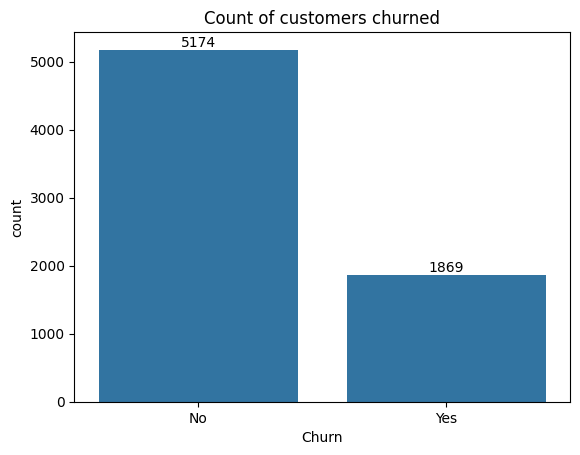

In [ ]:
ax =sns.countplot(x = "Churn" , data=data)
ax.bar_label(ax.containers[0])
plt.title("Count of customers churned")
plt.show()

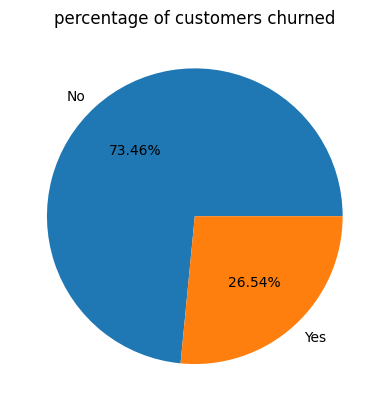

In [ ]:
gb = data.groupby('Churn').agg({'Churn':"count"})
plt.pie(gb['Churn'],labels=gb.index,autopct="%1.2f%%")
plt.title("percentage of customers churned")
plt.show()


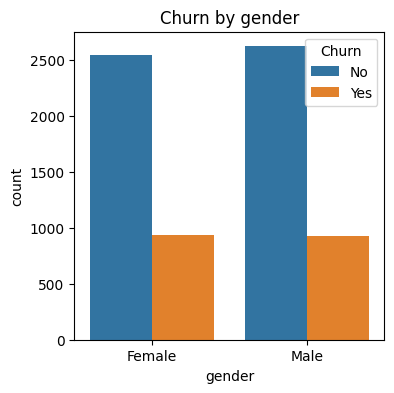

In [ ]:
plt.figure(figsize=(4,4))
sns.countplot (x="gender",data=data,hue="Churn")
plt.title("Churn by gender")
plt.show()

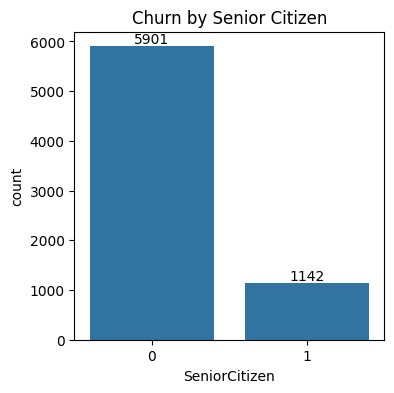

In [ ]:
plt.figure(figsize=(4,4))
ax = sns.countplot (x="SeniorCitizen",data=data)
ax.bar_label(ax.containers[0])
plt.title("Churn by Senior Citizen")
plt.show()

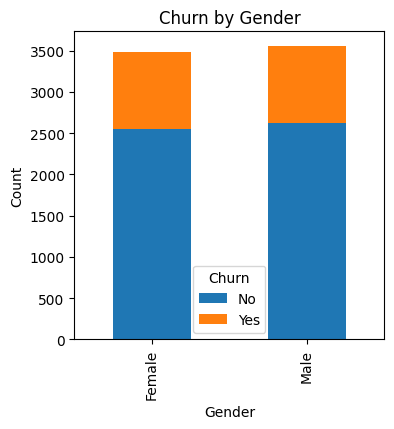

In [ ]:
churn_gender = pd.crosstab(data["gender"], data["Churn"])

churn_gender.plot(
    kind="bar",
    stacked=True,
    figsize=(4,4)
)

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.show()

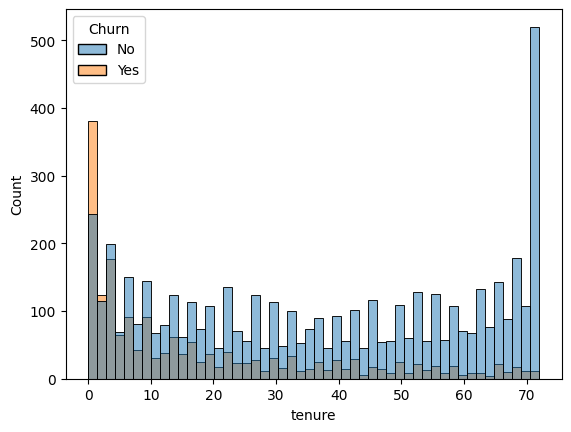

In [ ]:
sns.histplot(x="tenure",data=data,bins=50,hue="Churn")
plt.show()

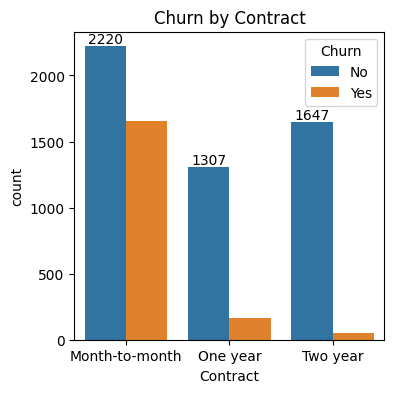

In [13]:
plt.figure(figsize=(4,4))
ax = sns.countplot (x="Contract",data=data,hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn by Contract")
plt.show()

In [9]:
data.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

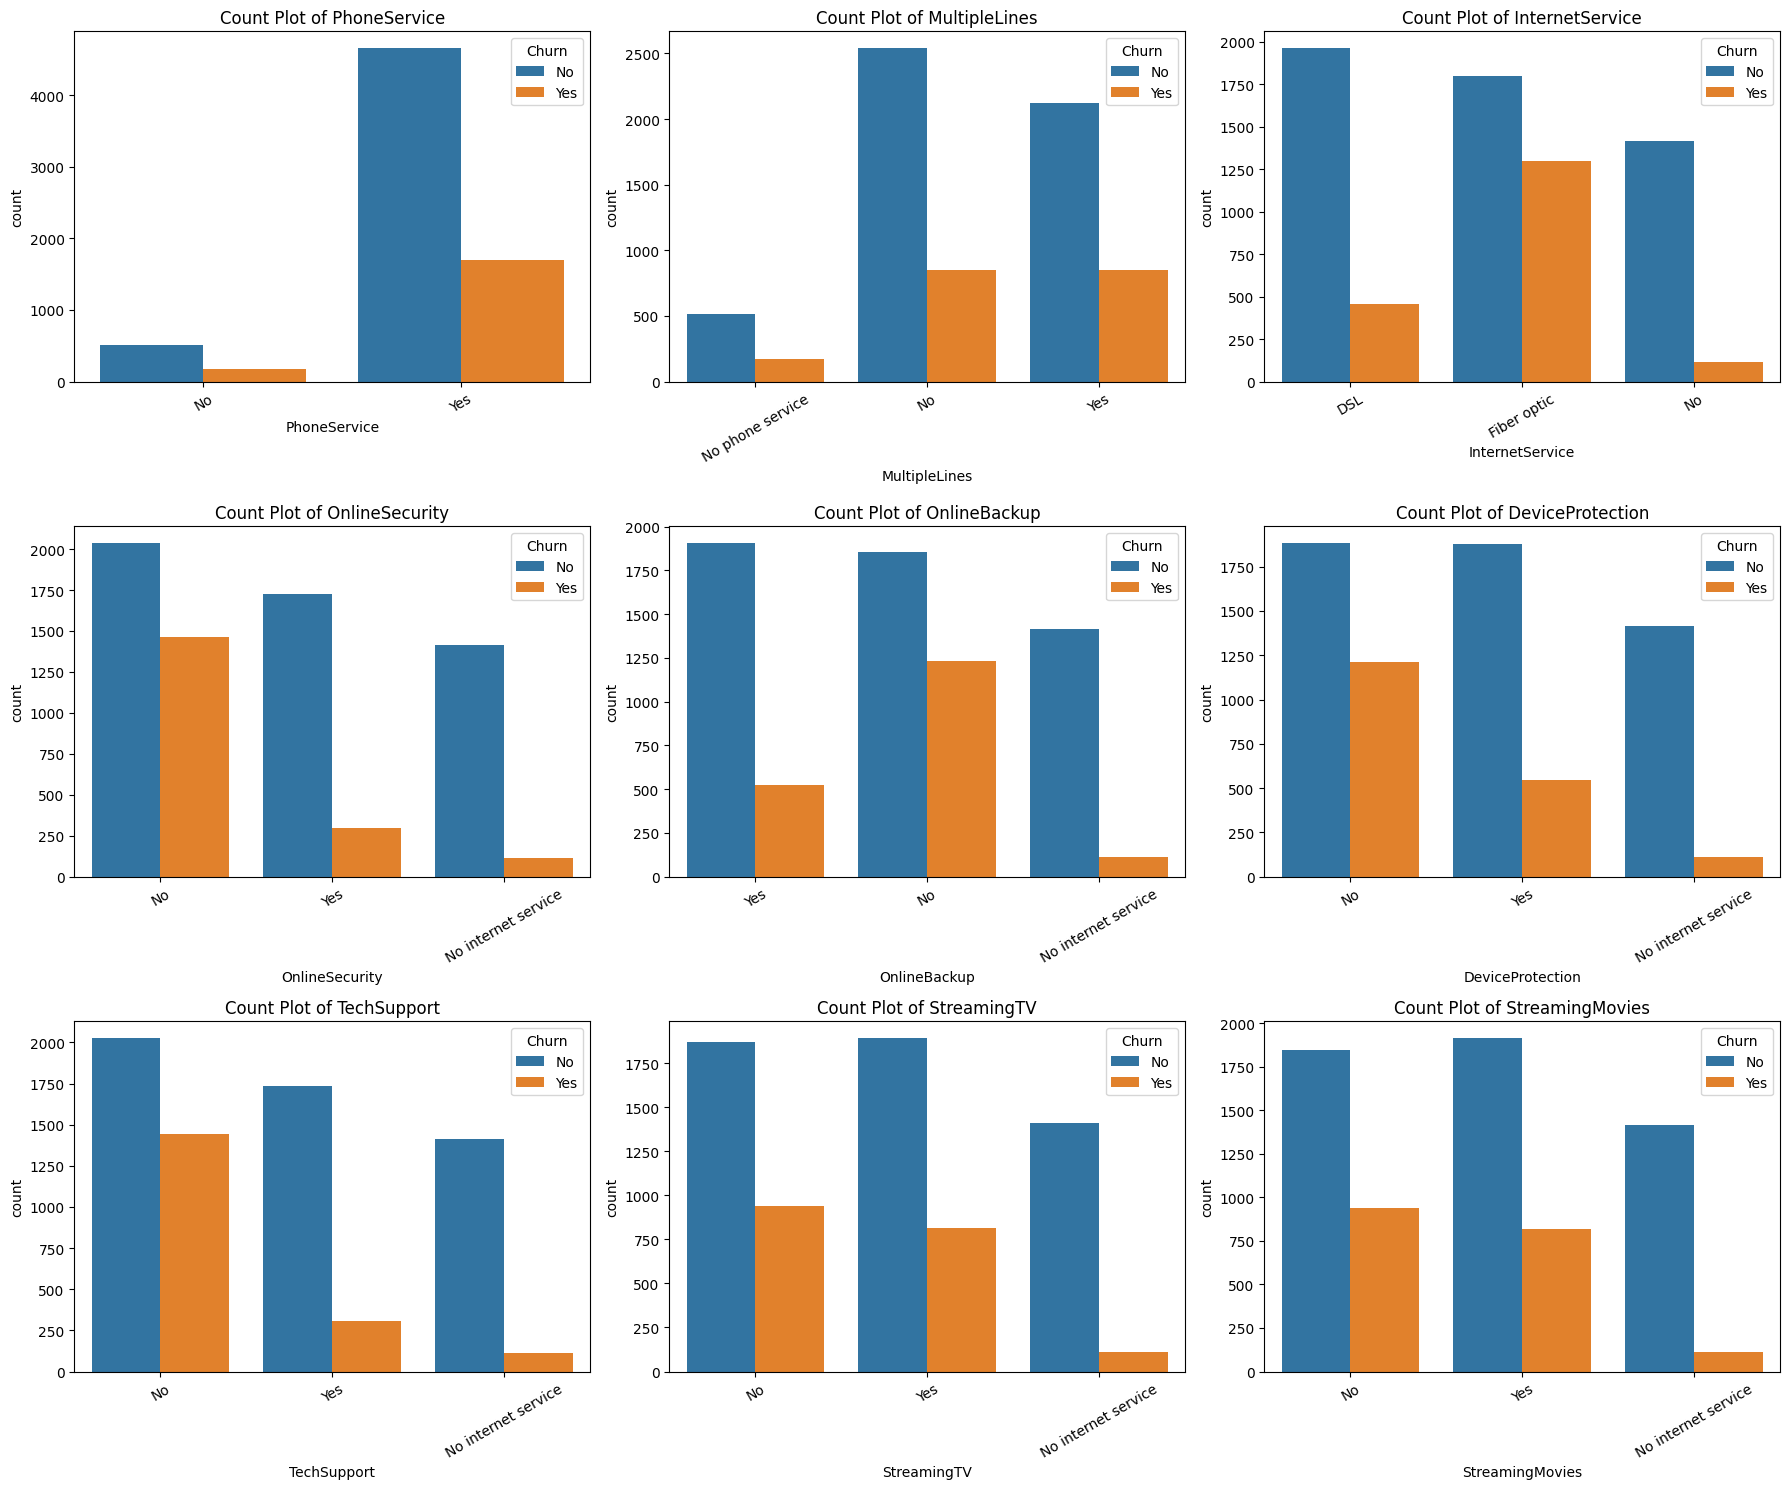

In [12]:

# List of columns
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))

# Flatten axes for easy looping
axes = axes.flatten()

# Loop through columns and create countplots
for i, col in enumerate(columns):
    sns.countplot(
        x=col,
        data=data,
        ax=axes[i] , hue=data["Churn"]
    ) 
    
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=30)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

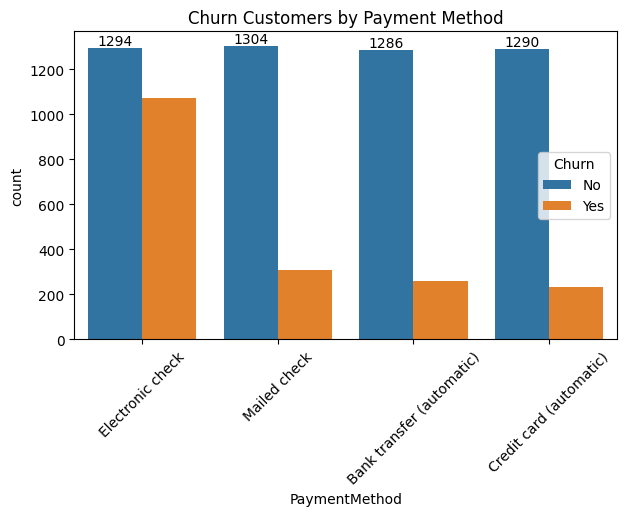

In [15]:
plt.figure(figsize=(7,4))
ax = sns.countplot (x="PaymentMethod",data=data,hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn Customers by Payment Method")
plt.xticks(rotation=45)
plt.show()